### Analisis de pelicula radiocromica para la posicion inicial de la fuente de braquiterapia

Realizaremos un procedimiento similar al del analisis de placas mensual.

### Librerias

In [1]:
import numpy as np
import scipy as sp
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftfreq
from scipy.fft import fftshift, ifftshift
from scipy.signal import convolve2d

import imageio

import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib import colormaps
import pint

from PIL import Image

u = pint.UnitRegistry()

In [2]:
print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'okabe_ito', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_s

### Funciones auxiliares

In [3]:
def normalize_image(image):
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return normalized_image

def intensidad_del_campo(campo):
    intensidad_espectro_imagen = np.abs(campo)**2
    return intensidad_espectro_imagen


### Placa a analizar

Fue recomendado, casi que por obligacion usar las 3 capas RGB.

In [4]:
ruta_imagen = '/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/braqui_00.jpeg'

placa_analizada = cv2.bitwise_not(cv2.imread(ruta_imagen, 1))
placa_analizada_gray = cv2.bitwise_not(cv2.imread(ruta_imagen, 0))

In [5]:
tamano_pixel = 25.4/600 # Tamano del pixel a 600 dpi

QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no long

Puntos guardados (coordenadas [x, y]): [(192, 377), (189, 20)]


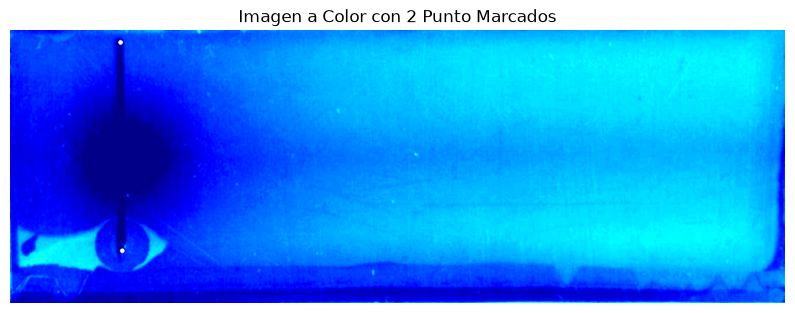

In [6]:
# --- 1. Aplicar mapa de color a la imagen base ---
# Convertimos el float32 [0.0, 1.0] a uint8 [0, 255] para aplicar el mapa de color de OpenCV
img_uint8 = (placa_analizada* 255).clip(0, 255).astype(np.uint8)

# Aplicar mapa de color (Puedes cambiar cv2.COLORMAP_JET por:
# COLORMAP_VIRIDIS, COLORMAP_HOT, COLORMAP_TURBO, COLORMAP_PLASMA, COLORMAP_BONE)
placa_color_bgr = cv2.applyColorMap(img_uint8, cv2.COLORMAP_JET)

# Convertir de vuelta a float32 [0.0, 1.0] para trabajar uniformemente
placa_color = placa_color_bgr.astype(np.float32) / 255.0

puntos = []


def seleccionar_puntos(event, x, y, flags, param):
    global puntos, placa_color

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 2:
        puntos.append((x, y))

        # Dibujar punto con intensidad de contraste sobre el mapa de calor
        # (1.0, 1.0, 1.0) = Blanco puro | (0.0, 0.0, 0.0) = Negro puro
        cv2.circle(placa_color, (x, y), 4, (1.0, 1.0, 1.0), -1)


# --- 2. Interfaz interactiva OpenCV ---
cv2.namedWindow("Seleccionar 2 Puntos", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Seleccionar 2 Puntos", seleccionar_puntos)
cv2.resizeWindow("Seleccionar 2 Puntos", 1280, 720)

while True:
    cv2.imshow("Seleccionar 2 Puntos", placa_color)

    key = cv2.waitKey(1) & 0xFF
    if key == 27 or len(puntos) == 2:
        if len(puntos) == 2:
            cv2.imshow("Seleccionar 2 Punto", placa_color)
            cv2.waitKey(300)
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

# --- 3. Renderizado inline dentro del Notebook ---
print(f"Puntos guardados (coordenadas [x, y]): {puntos}")

# Convertir BGR a RGB para mostrar exactamente lo mismo en Matplotlib
placa_color_rgb = cv2.cvtColor(
    (placa_color * 255).astype(np.uint8), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(placa_color_rgb)
plt.title("Imagen a Color con 2 Punto Marcados")
plt.axis("off")
plt.show()

plt.imsave('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_0.jpeg', placa_color_rgb)

Debemos ahora poder alinearla automaticamente, teniendo las coordenadas, podemos identificar la inclinacion respecto a la vertical.



In [7]:
tetha_0 = -1 * np.degrees(np.arctan((puntos[1][0] - puntos[0][0])/(puntos[1][1] - puntos[0][1])))
print(tetha_0)

-0.48146580583835247


Necesito identificar y especificar adecuadamente mi centro de rotacion, que debe ser el centro de la linea, aaahg.

In [8]:
centro_rotacion = ((puntos[1][0] + puntos[0][0])//2, (puntos[1][1] + puntos[0][1])//2)

print(centro_rotacion)

(190, 198)


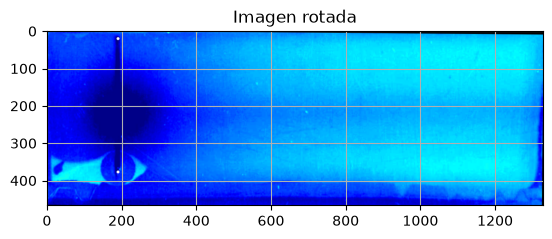

In [9]:
placa_matriz_transformacion = cv2.getRotationMatrix2D(
    centro_rotacion,
    tetha_0, 1)

placa_rotada = cv2.warpAffine(placa_color_rgb, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_color_rgb)[1], np.shape(placa_color_rgb)[0]))

plt.imshow(placa_rotada, cmap = 'jet')
plt.title('Imagen rotada')
plt.grid()
plt.show()

Pero ahora donde quedan esos puntos, los necesitamos para saber donde hacer los cortes.

In [10]:
type(puntos)

list

In [11]:
type(np.array(puntos))

numpy.ndarray

In [12]:
puntos

[(192, 377), (189, 20)]

In [13]:
np.shape(placa_matriz_transformacion)

(2, 3)

In [14]:
arr_puntos = np.array(puntos)

puntos_rotados_tetha = cv2.transform(
    arr_puntos.reshape(-1, 1, 2),
    placa_matriz_transformacion
)

puntos_rotados_tetha = puntos_rotados_tetha.reshape(-1, 2).tolist()

print(f"Nueva posicion puntos de referencia: {puntos_rotados_tetha}")

Nueva posicion puntos de referencia: [[190, 377], [190, 20]]


In [15]:
arr_puntos.reshape(-1, 1, 2)

array([[[192, 377]],

       [[189,  20]]])

In [16]:
type(puntos)

list

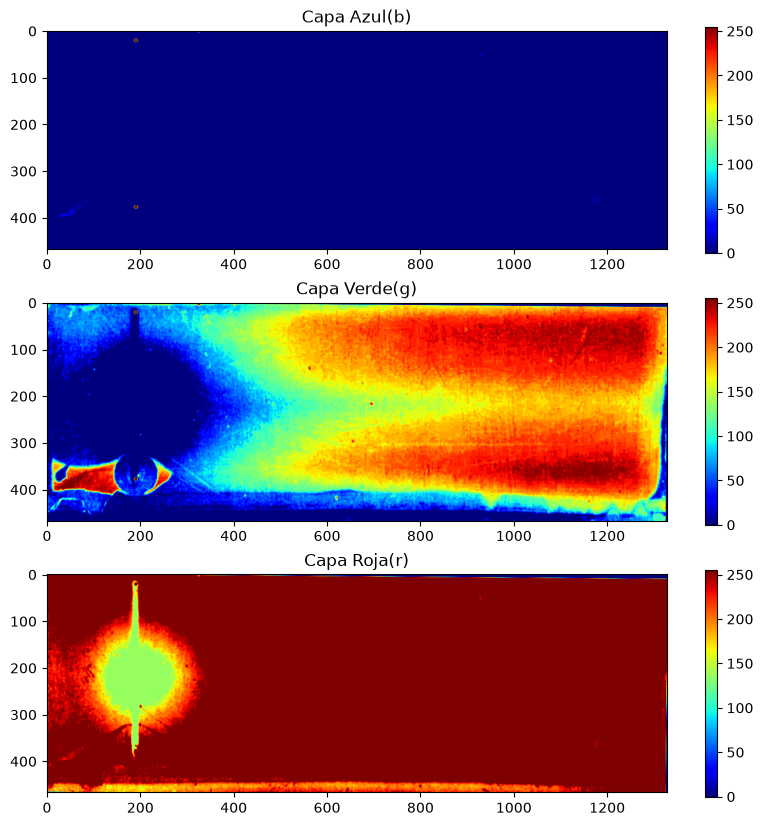

In [17]:
b, g, r = cv2.split(placa_rotada)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3) # Numero filas, columnas, posicion especifica.
plt.imshow(r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

In [18]:
type(b)

numpy.ndarray

In [19]:
cv2.bitwise_not(b)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(467, 1328), dtype=uint8)

## Perfil de la placa

Utilizaremos la misma estrategia para limpiar los bordes y evitar los artefactos en la periferia.

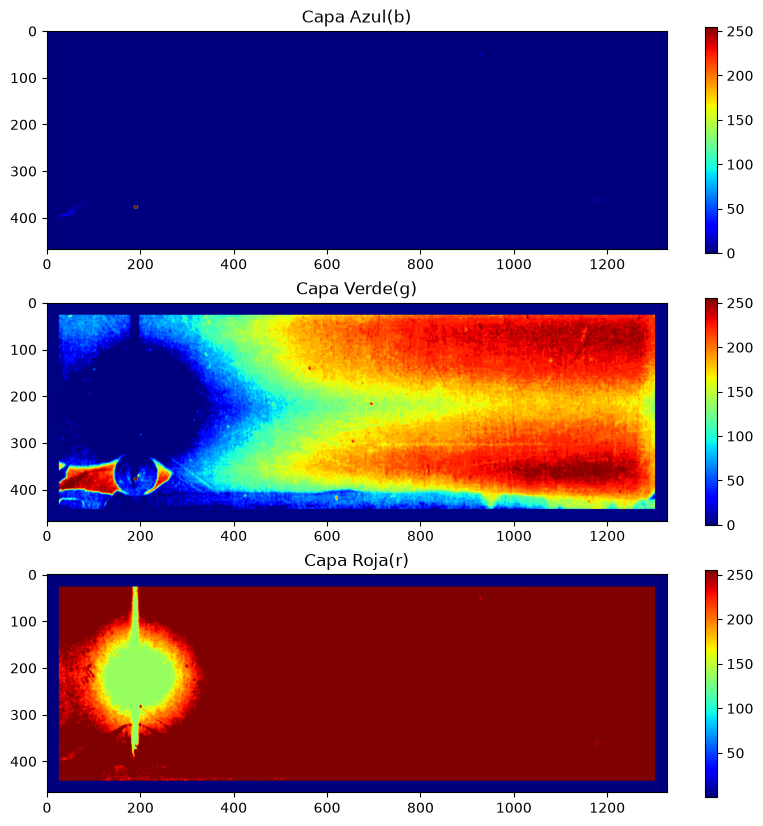

In [20]:
grosor_marco = 50

rectangulo_borde_b = cv2.rectangle(b, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)
rectangulo_borde_g = cv2.rectangle(g, (0, 0), (np.shape(g)[1], np.shape(g)[0]), 1, grosor_marco)
rectangulo_borde_r = cv2.rectangle(r, (0, 0), (np.shape(r)[1], np.shape(r)[0]), 1, grosor_marco)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(rectangulo_borde_b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(rectangulo_borde_g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(rectangulo_borde_r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

In [21]:
np.shape(b)

(467, 1328)

## Acondicionamiento de la imagen

Obligatoriamente hay que invertir estas imagenes porque sino la curva queda "alreves". Porque como vemos  continuacion sin invertir antes la imagen, el maximo y el valor de la pelicula virgen coinciden, por lo que la normalizacion falla.

Aqui puede que no sea necesario hacer la correccion de piso y techo porque no debemos medir alturas solo alineacion.

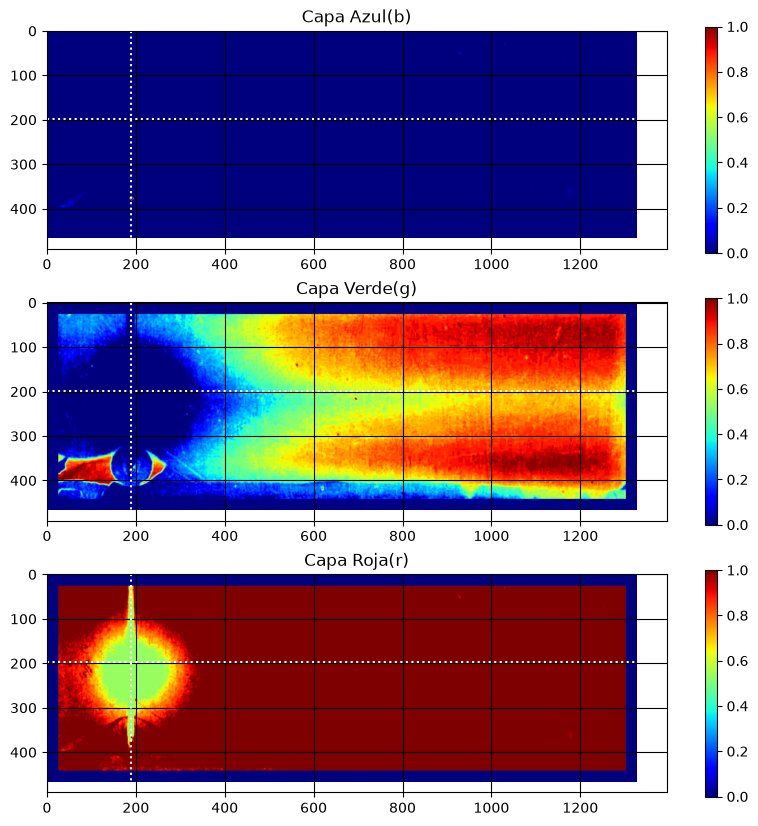

In [22]:
placa_recorte_borde_b = normalize_image(rectangulo_borde_b)
placa_recorte_borde_g = normalize_image(rectangulo_borde_g)
placa_recorte_borde_r = normalize_image(rectangulo_borde_r)


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(placa_recorte_borde_b, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_b)[0],
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_b)[1],
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(placa_recorte_borde_g, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_g)[0],
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_g)[1],
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(placa_recorte_borde_r, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_r)[0],
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_r)[1],
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Roja(r)')

plt.show()

In [23]:
zona_ignorada_marco = grosor_marco + 1

valor_pelicula_centro_b = placa_recorte_borde_b[centro_rotacion[1]][centro_rotacion[0]] 
print(f"Valor de centro blue: {valor_pelicula_centro_b}")

valor_pelicula_centro_g = placa_recorte_borde_g[centro_rotacion[1]][centro_rotacion[0]] 
print(f"Valor de lcentro green: {valor_pelicula_centro_g}")

valor_pelicula_centro_r = placa_recorte_borde_r[centro_rotacion[1]][centro_rotacion[0]] 
print(f"Valor de centro red: {valor_pelicula_centro_r}")

Valor de centro blue: 0.0
Valor de lcentro green: 0.0
Valor de centro red: 0.531496062992126


Definiremos nuevamente el valor de la pelicula virgen, esta vez preferible en la esquina mas alejada.

Dado que el maximo no esta en un solo punto sino encerrado en un area de igual intensidad relativa, entonces lo que debemos hacer es sacarle el punto medio a esta region, preferiblemente primero garantizando que estamos en el centro exacto de la mancha, como? Sacamos el array.

Con esos dos puntos podemos trazar un centro o un eje sobre el cual hacer el corte a nivel vertical, debe pasar por el centro de la recta, no necesariamente verticalmente, sino primero horizontalemnte porque lo paralelo de la recta respecto a la vertical es lo que define la posicion vertical que debemos analizar, luego, elegiremos el centro de la region del maximo que sera el punto de corte horizontal.

Cuando roto la placa ya no coinciden las coordenadas de los centros. Con donde queda realmente el centro.

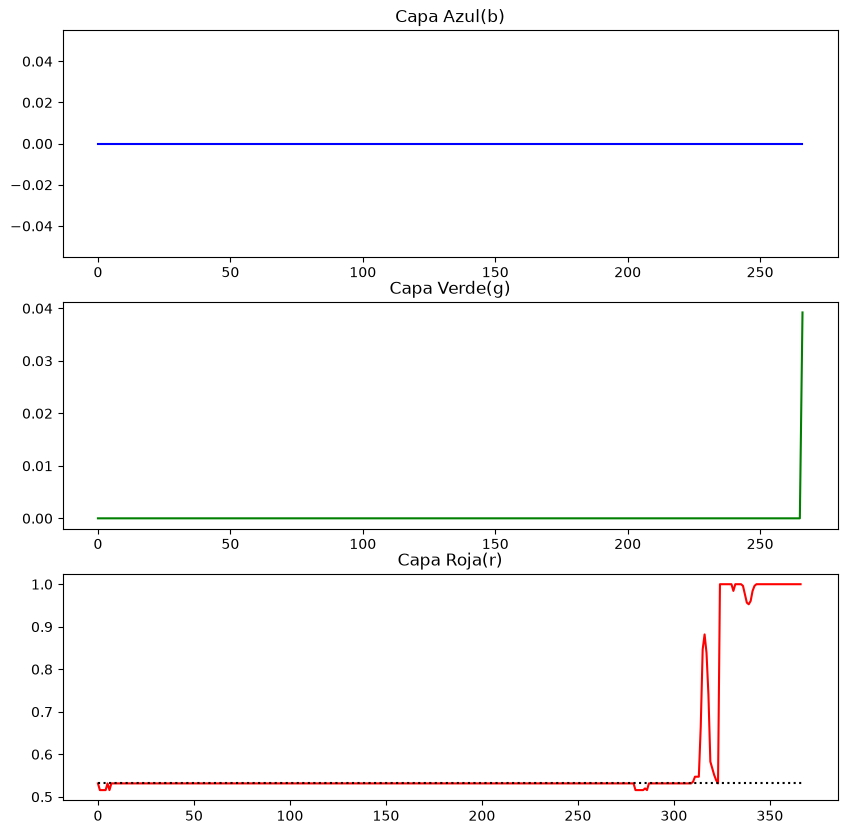

In [24]:
b_inplane = np.rot90(placa_recorte_borde_b)[
    np.shape(placa_recorte_borde_b)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_b)[0] - grosor_marco]

g_inplane = np.rot90(placa_recorte_borde_g)[
    np.shape(placa_recorte_borde_g)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_g)[0] - grosor_marco]

r_inplane = np.rot90(placa_recorte_borde_r)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_r)[0] - grosor_marco]

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_inplane[grosor_marco:np.shape(b_inplane)[0] - grosor_marco], color = 'blue')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_inplane[grosor_marco:np.shape(g_inplane)[0] - grosor_marco], color = 'green')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_inplane, color = 'red')
plt.hlines(valor_pelicula_centro_r, 0, np.shape(r_inplane)[0], colors = "Black", linestyles = ':')
plt.title('Capa Roja(r)')

plt.show()

El corte anterior realmente no tiene mucha informacion util, pues es verdad, estamos haciendo el corte justo por donde pasa la linea. Ya tenemos toda la informacion de la linea, incluso el centro, es alli por donde debemos hacer el corte.

Hay que tener en cuenta que la aplicacion funciona con python 3.11.16, changos.

Centro de la region del minimo en Placa_Green: 139
Desfase al centro de referencia: 51
Desfase al centro de referencia: 2.159 mm
Centro de la region del minimo en Placa_Red: 149
Desfase al centro de referencia: 41
Desfase al centro de referencia: 1.736 mm


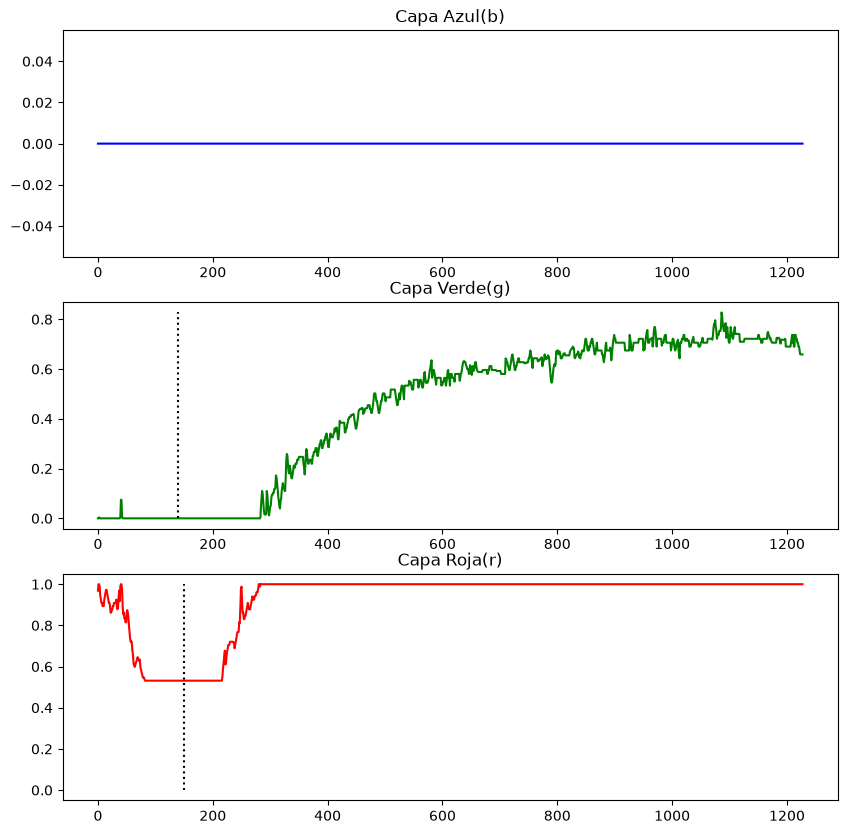

In [25]:
b_crossplane = placa_recorte_borde_b[
    centro_rotacion[1]
][grosor_marco:np.shape(placa_recorte_borde_b)[1] - grosor_marco]

g_crossplane = placa_recorte_borde_g[
    centro_rotacion[1]
][grosor_marco:np.shape(placa_recorte_borde_g)[1] - grosor_marco]

r_crossplane = placa_recorte_borde_r[
    centro_rotacion[1]
][grosor_marco:np.shape(placa_recorte_borde_r)[1] - grosor_marco]

# Hallamos los centros para graficarlos de una vez
arr_plan_g = np.where(g_crossplane == valor_pelicula_centro_g)[0]
ancho_plan_g = len(arr_plan_g)

centro_plan_g = (ancho_plan_g//2) + int(arr_plan_g[0])
diff_centro_g = centro_rotacion[0] - centro_plan_g
print(f"Centro de la region del minimo en Placa_Green: {centro_plan_g}")
print(f"Desfase al centro de referencia: {diff_centro_g}")
print(f"Desfase al centro de referencia: {np.round(diff_centro_g * tamano_pixel, 3)} mm")


arr_plan_r = np.where(r_crossplane == valor_pelicula_centro_r)[0]
ancho_plan_r = len(arr_plan_r)

centro_plan_r = (ancho_plan_r//2) + int(arr_plan_r[0])
diff_centro_r = centro_rotacion[0] - centro_plan_r
print(f"Centro de la region del minimo en Placa_Red: {centro_plan_r}")
print(f"Desfase al centro de referencia: {diff_centro_r}")
print(f"Desfase al centro de referencia: {np.round(diff_centro_r * tamano_pixel, 3)} mm")

# Graficamos
plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_crossplane, color = 'blue')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_crossplane, color = 'green')
plt.vlines(centro_plan_g, 0, np.max(g_crossplane), colors = 'Black', linestyles = ':')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_crossplane, color = 'red')
plt.vlines(centro_plan_r, 0, np.max(r_crossplane), colors = 'Black', linestyles = ':')
plt.title('Capa Roja(r)')

plt.show()

Ahora, definiremos el ancho del valle, para hallar su centro, luego contrastamos la posicion de ese centro con respecto al centro hallado por el trazo de las lineas. Ese centro queda realmente donde es? Porque segun el calculo depende de la longitud de la linea que trazamos. Luego contrastamos estos dos metodos porque hayar el centro con cualquier otro punto de referencia tambien aporta un error.

In [26]:
np.where(g_crossplane == valor_pelicula_centro_g)[0]

array([  0,   1,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  43,
        44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
        83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
        96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108,
       109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
       135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
       148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
       161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173,
       174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 18

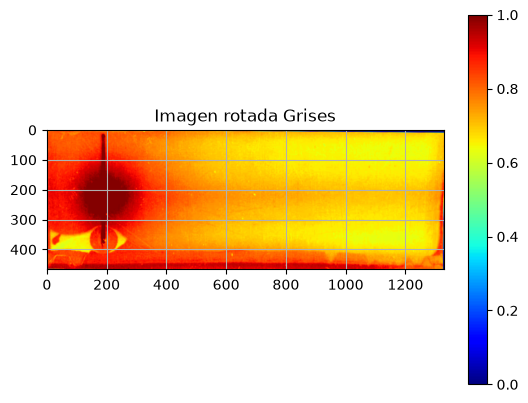

In [27]:
placa_rotada_gray = cv2.warpAffine(placa_analizada_gray, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_analizada_gray)[1], np.shape(placa_analizada_gray)[0]))

placa_gris = normalize_image(placa_rotada_gray)

plt.imshow(placa_gris, cmap = 'jet')
plt.title('Imagen rotada Grises')
plt.grid()
plt.colorbar()
plt.show()

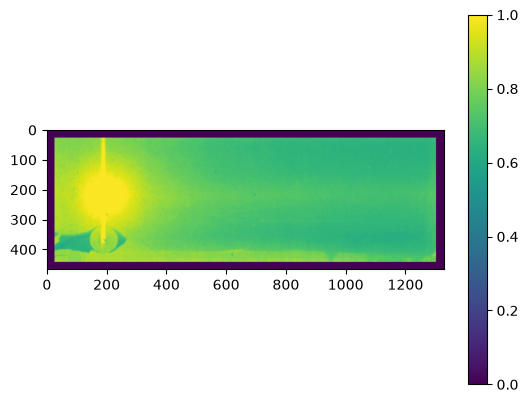

In [28]:
placa_gris_borde = cv2.rectangle(placa_gris, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)

plt.imshow(placa_gris_borde)
plt.colorbar()
plt.show()

In [29]:
valor_pelicula_centro_gray = placa_gris_borde[centro_rotacion[1]][centro_rotacion[0]] 
print(f"Valor de centro blue: {valor_pelicula_centro_gray}")

Valor de centro blue: 0.996078431372549


In [30]:
np.shape(placa_recorte_borde_b)

(467, 1328)

Centro de la region del minimo en Placa_Gray; 134
Desfase al centro de referencia: 56 px
Desfase al centro de referencia: 2.3706666666666667 mm


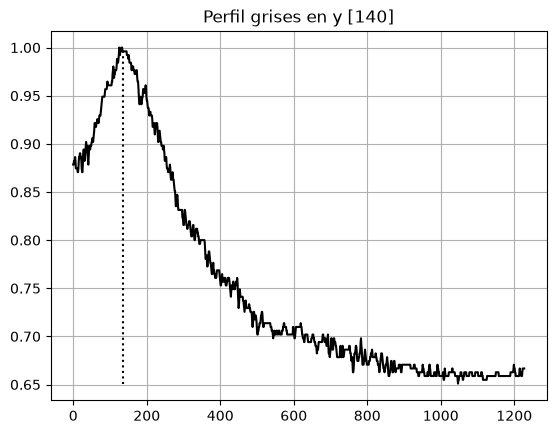

In [31]:
ds = -50

gray_crossplane = placa_gris_borde[
    centro_rotacion[1] + ds
][grosor_marco:np.shape(placa_gris_borde)[1] - grosor_marco]

arr_plan_gray = np.where(gray_crossplane == valor_pelicula_centro_gray)[0]
ancho_plan_gray = len(arr_plan_gray)

centro_plan_gray = (ancho_plan_gray//2) + int(arr_plan_gray[0])
diff_centro_gray = centro_rotacion[0] - centro_plan_gray
print(f"Centro de la region del minimo en Placa_Gray; {centro_plan_gray}")
print(f"Desfase al centro de referencia: {diff_centro_gray} px")
print(f"Desfase al centro de referencia: {diff_centro_gray * tamano_pixel} mm")

plt.plot(gray_crossplane, color = 'Black')
plt.grid()
plt.title(f"Perfil grises en y [{centro_rotacion[0] + ds}]")
plt.vlines(centro_plan_gray, np.min(gray_crossplane), np.max(gray_crossplane), colors = 'Black', linestyles = ':')
plt.show()

## Calibracion

Vamos a crear una distribucion artificial para calibrar la placa.

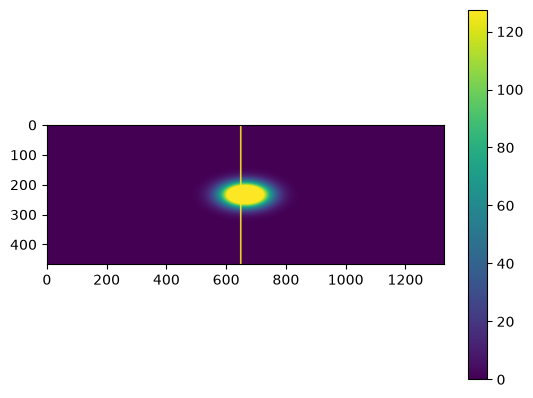

In [32]:
ancho, alto = np.shape(placa_analizada)[0], np.shape(placa_analizada)[1]
centro_xcal, centro_ycal = alto//2, ancho//2
sigma = 75

x_cal = np.arange(0, alto)
y_cal = np.arange(0, ancho)
X, Y = np.meshgrid(x_cal, y_cal)

frente_onda = np.exp(-(2 * (X - centro_xcal) ** 2 + 8 * (Y - centro_ycal) ** 2) / (2 * sigma ** 2))

frente_onda_8bit = np.uint8(frente_onda * 255)

dev_center_cal = centro_xcal - 15
cv2.line(frente_onda_8bit, (dev_center_cal, 0), (dev_center_cal, np.shape(frente_onda_8bit)[1]), 0.5 * 255, 3)

frente_saturado = np.where(frente_onda_8bit >= (0.5 * 255), (0.5 * 255), frente_onda_8bit)

plt.imshow(frente_saturado)
plt.colorbar()
plt.show()

plt.imsave('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_cal0.jpeg', frente_saturado)

In [33]:
frente_onda_8bit[dev_center_cal][0]

IndexError: index 649 is out of bounds for axis 0 with size 467

In [ ]:
placa_cal = cv2.imread('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_cal0.jpeg', 0)

plt.imshow(placa_cal, cmap = 'jet')
plt.colorbar()
plt.show()